<a href="https://colab.research.google.com/github/s3hito/3DV/blob/main/3DV/labs/fixed_demo_hloc_carbo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this notebook, we will build a 3D map of a scene from a small set of images and then localize an image downloaded from the Internet. This demo was contributed by [Philipp Lindenberger](https://github.com/Phil26AT/).

In [7]:
!wget https://liveuniba-my.sharepoint.com/personal/kocur15_uniba_sk/Documents/BcPraktikum/matfyz.tar.gz?ga=1

--2026-05-11 17:30:43--  https://liveuniba-my.sharepoint.com/personal/kocur15_uniba_sk/Documents/BcPraktikum/matfyz.tar.gz?ga=1
Resolving liveuniba-my.sharepoint.com (liveuniba-my.sharepoint.com)... 52.105.141.39, 2a01:111:f402:f086::39
Connecting to liveuniba-my.sharepoint.com (liveuniba-my.sharepoint.com)|52.105.141.39|:443... connected.
HTTP request sent, awaiting response... 403 FORBIDDEN
2026-05-11 17:30:44 ERROR 403: FORBIDDEN.



In [4]:
#!rm -rf ./datasets/carbo

In [21]:
!tar -xvzf matfyz.tar.gz -C ./datasets/matfyz/mapping
!tar -xvzf carbo.tar.gz -C ./datasets/carbo

IMG_20221121_160012.jpg
IMG_20221121_160018.jpg
IMG_20221121_160023.jpg
IMG_20221121_160034.jpg
IMG_20221121_160045.jpg
IMG_20221121_160048.jpg
IMG_20221121_160051.jpg
IMG_20221121_160104.jpg
IMG_20221121_160112.jpg
IMG_20221121_160115.jpg
IMG_20221121_160123.jpg
IMG_20221121_160124.jpg
IMG_20221121_160132.jpg
IMG_20221121_160153.jpg
IMG_20221121_160156.jpg
IMG_20221121_160204.jpg
IMG_20221121_160207.jpg
IMG_20221121_160217.jpg
IMG_20221121_160223.jpg
IMG_20221121_160232.jpg
IMG_20221121_160255.jpg
IMG_20221121_160301.jpg
IMG_20221121_160327.jpg
IMG_20221121_160330.jpg


In [18]:
!pwd

/content/Hierarchical-Localization


In [1]:
!git clone --quiet --recursive https://github.com/cvg/Hierarchical-Localization/
%cd Hierarchical-Localization
!pip install --progress-bar off --quiet -e .
!pip install --progress-bar off --quiet --upgrade plotly

import tqdm, tqdm.notebook
tqdm.tqdm = tqdm.notebook.tqdm  # notebook-friendly progress bars
from pathlib import Path

from hloc import extract_features, match_features, reconstruction, visualization, pairs_from_exhaustive
from hloc.visualization import plot_images, read_image
from hloc.utils import viz_3d

fatal: destination path 'Hierarchical-Localization' already exists and is not an empty directory.
/content/Hierarchical-Localization
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


# Setup
Here we define some output paths. We will use SuperPoint local features with the SuperGlue matcher, but it's easy to switch to other features like SIFT or R2D2.

In [2]:
images = Path('datasets/carbo')
outputs = Path('outputs/demo/')
!rm -rf $outputs
sfm_pairs = outputs / 'pairs-sfm.txt'
loc_pairs = outputs / 'pairs-loc.txt'
sfm_dir = outputs / 'sfm'
features = outputs / 'features.h5'
matches = outputs / 'matches.h5'

feature_conf = extract_features.confs['superpoint_aachen']
matcher_conf = match_features.confs['superglue']

# 3D mapping
First we list the images used for mapping. These are all day-time shots of Sacre Coeur.

17 mapping images


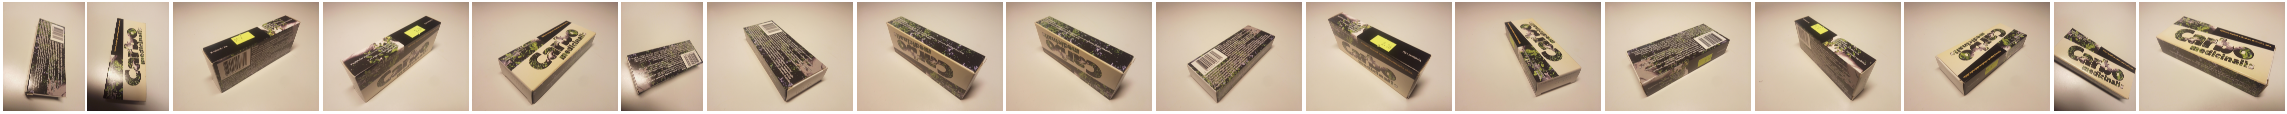

In [6]:
references = [str(p.relative_to(images)) for p in (images / 'mapping/').iterdir()]
print(len(references), "mapping images")
plot_images([read_image(images / r) for r in references], dpi=25)

Then we extract features and match them across image pairs. Since we deal with few images, we simply match all pairs exhaustively. For larger scenes, we would use image retrieval, as demonstrated in the other notebooks.

In [7]:
extract_features.main(feature_conf, images, image_list=references, feature_path=features)
pairs_from_exhaustive.main(sfm_pairs, image_list=references)
match_features.main(matcher_conf, sfm_pairs, features=features, matches=matches);

[2026/05/11 17:59:32 hloc INFO] Extracting local features with configuration:
{'model': {'max_keypoints': 4096, 'name': 'superpoint', 'nms_radius': 3},
 'output': 'feats-superpoint-n4096-r1024',
 'preprocessing': {'grayscale': True, 'resize_max': 1024}}


Loaded SuperPoint model


  0%|          | 0/17 [00:00<?, ?it/s]

[2026/05/11 17:59:35 hloc INFO] Finished exporting features.
[2026/05/11 17:59:35 hloc INFO] Found 136 pairs.
[2026/05/11 17:59:35 hloc INFO] Matching local features with configuration:
{'model': {'name': 'superglue',
           'sinkhorn_iterations': 50,
           'weights': 'outdoor'},
 'output': 'matches-superglue'}


Loaded SuperGlue model ("outdoor" weights)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 5 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  0%|          | 0/136 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 5 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
[2026/05/11 17:59:55 hloc INFO] Finished exporting matches.


The we run incremental Structure-from-Motion...

In [8]:
model = reconstruction.main(sfm_dir, images, sfm_pairs, features, matches, image_list=references)

[2026/05/11 17:59:55 hloc INFO] Writing COLMAP logs to outputs/demo/sfm/colmap.LOG.*
[2026/05/11 17:59:55 hloc INFO] Creating an empty database...
[2026/05/11 17:59:55 hloc INFO] Importing images into the database...
[2026/05/11 17:59:57 hloc INFO] Importing features into the database...


  0%|          | 0/17 [00:00<?, ?it/s]

[2026/05/11 17:59:57 hloc INFO] Importing matches into the database...


  0%|          | 0/136 [00:00<?, ?it/s]

[2026/05/11 17:59:57 hloc INFO] Performing geometric verification of the matches...
[2026/05/11 18:00:02 hloc INFO] Running 3D reconstruction...


Reconstruction 0:   0%|          | 0/17 [00:00<?, ?images/s, registered]

Reconstruction 1:   0%|          | 0/17 [00:00<?, ?images/s, registered]

[2026/05/11 18:00:06 hloc INFO] Reconstructed 1 model(s).
[2026/05/11 18:00:06 hloc INFO] Largest model is #0 with 11 images.
[2026/05/11 18:00:06 hloc INFO] Reconstruction statistics:
Reconstruction:
	num_rigs = 2
	num_cameras = 2
	num_frames = 11
	num_reg_frames = 11
	num_images = 11
	num_points3D = 977
	num_observations = 3354
	mean_track_length = 3.43296
	mean_observations_per_image = 304.909
	mean_reprojection_error = 1.37816
	num_input_images = 17


and display the reconstructed 3D model:

In [19]:
fig = viz_3d.init_figure()
viz_3d.plot_reconstruction(fig, model, color='rgba(255,0,0,0.5)', name="mapping", points_rgb=True)
fig.show()

We also visualize which keypoints were triangulated into the 3D model.

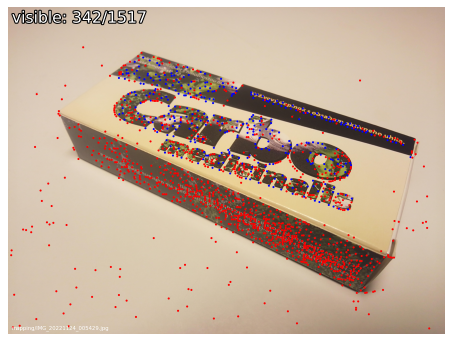

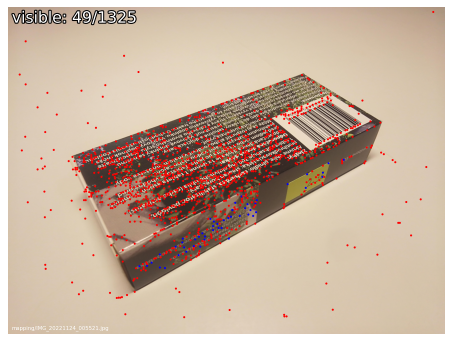

In [20]:
visualization.visualize_sfm_2d(model, images, color_by='visibility', n=2)

# Localization
Now that we have a 3D map of the scene, we can localize any image. To demonstrate this, we download [a night-time image from Wikimedia](https://commons.wikimedia.org/wiki/File:Paris_-_Basilique_du_Sacr%C3%A9_Coeur,_Montmartre_-_panoramio.jpg).

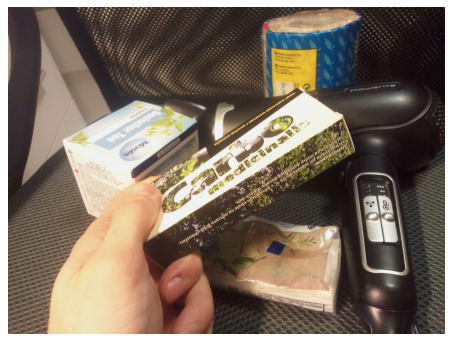

In [91]:
#url = "https://upload.wikimedia.org/wikipedia/commons/5/53/Paris_-_Basilique_du_Sacr%C3%A9_Coeur%2C_Montmartre_-_panoramio.jpg"
# try other queries by uncommenting their url
# url = "https://upload.wikimedia.org/wikipedia/commons/5/59/Basilique_du_Sacr%C3%A9-C%C5%93ur_%285430392880%29.jpg"
# url = "https://upload.wikimedia.org/wikipedia/commons/8/8e/Sacr%C3%A9_C%C5%93ur_at_night%21_%285865355326%29.jpg"
query = 'query/carbo_3.jpg'
#!mkdir -p $images/query && wget $url -O $images/$query -q
plot_images([read_image(images / query)], dpi=75)

Again, we extract features for the query and match them exhaustively with all mapping images that were successfully reconstructed.

In [97]:
references_registered = [model.images[i].name for i in model.reg_image_ids()]
extract_features.main(feature_conf, images, image_list=[query], feature_path=features, overwrite=True)
pairs_from_exhaustive.main(loc_pairs, image_list=[query], ref_list=references_registered)
match_features.main(matcher_conf, loc_pairs, features=features, matches=matches, overwrite=True);

[2026/05/11 18:45:13 hloc INFO] Extracting local features with configuration:
{'model': {'max_keypoints': 4096, 'name': 'superpoint', 'nms_radius': 3},
 'output': 'feats-superpoint-n4096-r1024',
 'preprocessing': {'grayscale': True, 'resize_max': 1024}}


Loaded SuperPoint model


  0%|          | 0/1 [00:00<?, ?it/s]

[2026/05/11 18:45:13 hloc INFO] Finished exporting features.
[2026/05/11 18:45:13 hloc INFO] Found 11 pairs.
[2026/05/11 18:45:13 hloc INFO] Matching local features with configuration:
{'model': {'name': 'superglue',
           'sinkhorn_iterations': 50,
           'weights': 'outdoor'},
 'output': 'matches-superglue'}


Loaded SuperGlue model ("outdoor" weights)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 5 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  0%|          | 0/11 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 5 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
[2026/05/11 18:45:16 hloc INFO] Finished exporting matches.


We read the EXIF data of the query to infer a rough initial estimate of camera parameters like the focal length. Then we estimate the absolute camera pose using PnP+RANSAC and refine the camera parameters.

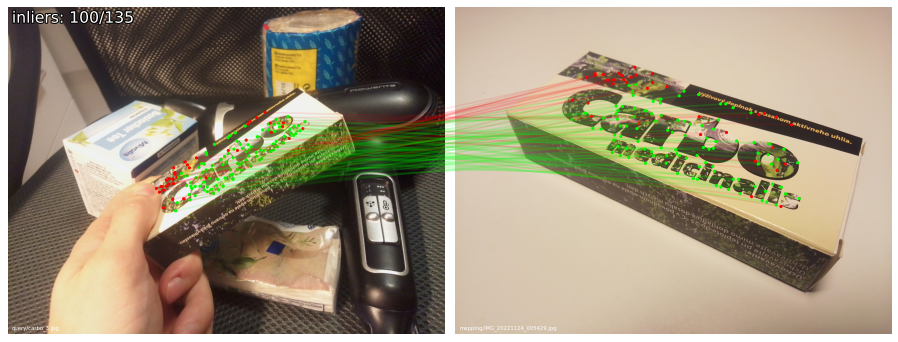

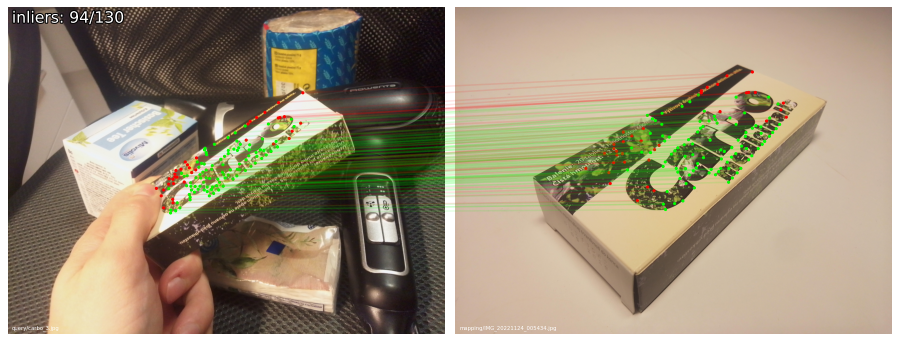

In [98]:
import pycolmap
from hloc.localize_sfm import QueryLocalizer, pose_from_cluster

camera = pycolmap.infer_camera_from_image(images / query)
ref_ids = [model.find_image_with_name(n).image_id for n in references_registered]
conf = {
    'estimation': {'ransac': {'max_error': 12}},
    'refinement': {'refine_focal_length': True, 'refine_extra_params': True},
}
localizer = QueryLocalizer(model, conf)
ret, log = pose_from_cluster(localizer, query, camera, ref_ids, features, matches)
# print(f'found {ret["num_inliers"]}/{len(ret["inliers"])} inlier correspondences.')
visualization.visualize_loc_from_log(images, query, log, model)

We visualize the correspondences between the query images a few mapping images. We can also visualize the estimated camera pose in the 3D map.

In [28]:
pose=ret['cam_from_world']
viz_3d.plot_camera_colmap(fig, pose, camera, color='rgba(0,255,0,0.5)', name=query, fill=True)
# visualize 2D-3D correspodences
import numpy as np
inl_3d = np.array([model.points3D[pid].xyz for pid in np.array(log['points3D_ids'])[ret['inlier_mask']]])
viz_3d.plot_points(fig, inl_3d, color="lime", ps=1, name=query)
fig.show()

In [99]:
import numpy as np
from sklearn.decomposition import PCA
import cv2
import matplotlib.pyplot as plt

pts = np.array([p.xyz for p in model.points3D.values()])


In [100]:
pca = PCA(n_components=3)
pca.fit(pts)

PCA(n_components=3)

In [66]:
ret['cam_from_world']

Rigid3d(rotation_xyzw=[0.105898, 0.518252, 0.556109, 0.641049], translation=[-0.699133, 0.0652492, 8.70557])

In [65]:
 ret['cam_from_world'].matrix()

array([[-0.15568439, -0.60322264,  0.78223067, -0.69913292],
       [ 0.82274946,  0.35905668,  0.44063775,  0.06524915],
       [-0.54666781,  0.71218028,  0.44040158,  8.705569  ]])

In [94]:
axes = pca.components_
scale = pca.singular_values_
center = pca.mean_

In [70]:
axes

array([[-0.33115131, -0.66287981,  0.6715126 ],
       [ 0.89408626,  0.00701823,  0.44783982],
       [-0.3015768 ,  0.74869293,  0.59034764]])

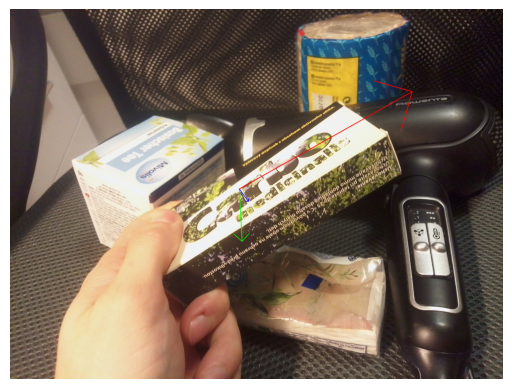

In [101]:
#ret, log = pose_from_cluster(localizer, query, camera, ref_ids, features, matches)

query_img = cv2.imread(str(images / query))
ret, log = pose_from_cluster(localizer, query, camera, ref_ids, features, matches)
P = camera.calibration_matrix() @ ret['cam_from_world'].matrix()

h = P @ np.append(center,1.0)
origin_2d = (int(h[0]/h[2]), int(h[1]/h[2]))

colors = [(0,0,255), (0,255,0), (255,0,0)]
for i in range(3):
  pt3d = center + axes[i] * scale[i] * 0.1
  h = P @ np.append(pt3d, 1.0)
  end_2d = (int(h[0]/h[2]), int(h[1]/h[2]))


  cv2.arrowedLine(query_img, origin_2d, end_2d,colors[i], 3, tipLength=0.2),
#cv2.projectPoints(pts, ret['cam_from_world'].matrix(), np.zeros(3), camera.calibration_matrix(), np.zeros(5))
plt.imshow(query_img[:, :, ::-1])
plt.axis('off')
plt.show()

In [74]:
query

'query/carbo_1.jpg'

In [44]:
twoD_projection = P @ np.hstack((pca.singular_values_, 1))

In [45]:
twoD_projection_hom = twoD_projection[0:2] / twoD_projection[2]

In [46]:
twoD_projection_hom

array([-10104.94859194,  32714.77732748])